# K-Means Clustering — Bhavish (mine)
Customer segmentation using K-Means on `bhavish_customer_segmentation_dataset.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


## Load data

In [2]:
df = pd.read_csv('bhavish_customer_segmentation_dataset.csv')
df.head()

,customer_id,age,annual_income,spending_score,visit_frequency
0,1,59,37808.71,11,7
1,2,38,45376.90,83,14
2,3,35,38426.57,73,9
3,4,44,61630.50,59,5
4,5,57,52948.72,14,14


In [3]:
df.describe()

,customer_id,age,annual_income,spending_score,visit_frequency
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,40.503333,56050.198267,49.826667,7.813333
std,86.746758,12.955932,17426.419394,27.266490,2.855229
min,1.000000,18.000000,15000.000000,1.000000,1.000000
25%,75.750000,29.000000,42969.497500,26.000000,6.000000
50%,150.500000,40.000000,56645.385000,49.500000,8.000000
75%,225.250000,51.000000,70000.707500,72.000000,10.000000
max,300.000000,64.000000,100032.840000,99.000000,16.000000


## Feature selection and scaling

In [4]:
features = ['age', 'annual_income', 'spending_score', 'visit_frequency']
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Elbow method to choose k

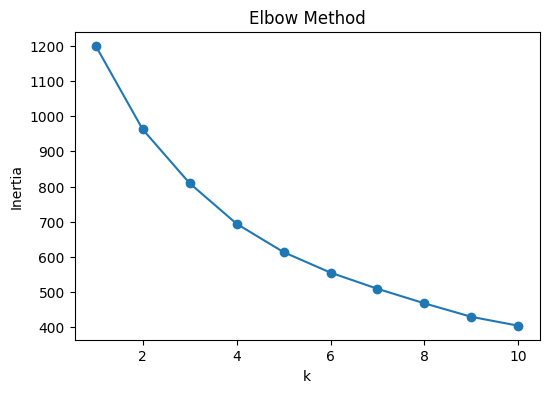

In [5]:
inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

## Fit K-Means and evaluate with silhouette score
This version explicitly evaluates several values of k with the silhouette score instead of just eyeballing the elbow, and uses PCA for a 2D view of the cluster separation.

In [6]:
from sklearn.metrics import silhouette_score

scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

best_k = max(scores, key=scores.get)
print('Silhouette scores:', scores)
print('Best k:', best_k)

Silhouette scores: {2: 0.19178366407216668, 3: 0.18649933458497192, 4: 0.1983155018369942, 5: 0.20585507260910604, 6: 0.20475811931169838, 7: 0.2021674105488942}
Best k: 5


In [7]:
kmeans = KMeans(n_clusters=best_k, init='k-means++', random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)
df.head()

,customer_id,age,annual_income,spending_score,visit_frequency,cluster
0,1,59,37808.71,11,7,1
1,2,38,45376.90,83,14,4
2,3,35,38426.57,73,9,4
3,4,44,61630.50,59,5,1
4,5,57,52948.72,14,14,2


## Visualize clusters with PCA

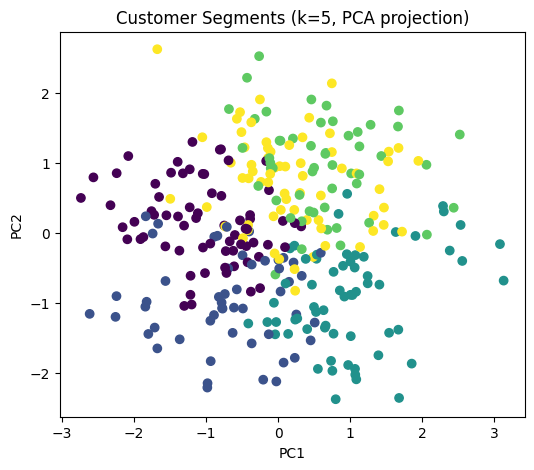

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(coords[:, 0], coords[:, 1], c=df['cluster'], cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Customer Segments (k={best_k}, PCA projection)')
plt.show()

## Cluster summary

In [9]:
summary = df.groupby('cluster')[features].mean()
summary['count'] = df['cluster'].value_counts().sort_index()
summary

,age,annual_income,spending_score,visit_frequency,count
cluster,,,,,
0,29.294118,46615.674265,32.323529,6.367647,68
1,53.269231,53135.986731,37.269231,5.173077,52
2,47.564516,67108.081935,31.822581,10.516129,62
3,29.307692,73027.567885,69.826923,7.846154,52
4,44.181818,44302.844091,78.909091,8.818182,66
